In [1]:
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI
from scipy.optimize import minimize
from stableemrifisher.utils import generate_PSD, padding, inner_product
from lisatools.sensitivity import get_sensitivity,CornishLISASens

In [2]:
m1 = 1e6
m2 = 10
a = 0.8 # 0.95
e0 = 0.4 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.2

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

In [3]:
import cupy as cp
xp=cp
# xp=np

In [4]:
chi2=0
deviation_included=True
evolve_1PA=True
evolve_primary=False
evolve_2PA=False
use_gpu=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
    "use_gpu":use_gpu
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
  #  "use_gpu":use_gpu
}

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
waveform_true = xp.array(waveform_true)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])

[0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [5]:
chi2=0
deviation_included=True
evolve_1PA=False
evolve_primary=False
evolve_2PA=False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
def to_minimize(x):
    log_m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = x
    add_args__ = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,\
                dev0p_,dev0e_,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
    m1_ = np.exp(log_m1_)
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS_, phiS_, qK, phiK, Phi_phi0_, Phi_theta0, Phi_r0_, *add_args__, dt=dt, T=T))
    diff_inner=inner_product(waveform_temp,waveform_true,PSD,dt,use_gpu=use_gpu)
    norm_biased=np.sqrt(inner_product(waveform_temp,waveform_temp,PSD,dt,use_gpu=use_gpu))
    overlap=diff_inner/((norm_true)*norm_biased)
    return (overlap)

In [7]:
to_minimize(x=[np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e])
to_minimize([1.38155436e+01,  9.99981186e+00,  8.00037769e-01,7.49981068e+00,  4.00001137e-01,\
               7.85400513e-01,9.99999134e-01,8.99993271e-01,  3.99997763e-01,2.08333075e-05, -1.49625117e-05])

np.float64(0.9999998033123388)

In [7]:
bounds= [[np.float64(13.568653093100774), np.float64(14.062368022827773)],
 [np.float64(8.706642124877762), np.float64(11.293357875122238)],
 [np.float64(0.6360574301516815), np.float64(0.9639425698483186)],
 [np.float64(6.542070612746043), np.float64(8.457929387253957)],
 [np.float64(0.33599195062655846), np.float64(0.4640080493734416)],
 [np.float64(0.3203571257682239), np.float64(1.2504392010266727)],
 [np.float64(0.45707197343010797), np.float64(1.542928026569892)],
 [np.float64(-1.3476464074094237), np.float64(3.1476464074094235)],
 [np.float64(-0.27469774568237426), np.float64(1.0746977456823743)],
 [np.float64(-0.2272098720583124), np.float64(0.2272098720583124)],
 [np.float64(-0.3471389270982878), np.float64(0.3471389270982878)]]

In [8]:

iv=[ 1.38155436e+01,  9.99981186e+00,  8.00037769e-01,7.49981068e+00,  4.00001137e-01,  7.85400513e-01,9.99999134e-01,  8.99993271e-01,  3.99997763e-01,2.08333075e-05, -1.49625117e-05]
# result = minimize(to_minimize, iv,method="Nelder-Mead", bounds=bounds,tol=1e-10)

In [1]:
stationary_point=[1.38155436e+01,  9.99981186e+00,  8.00037769e-01,7.49981068e+00,  4.00001137e-01,  7.85400513e-01,9.99999134e-01,
            8.99993271e-01,  3.99997763e-01,2.08333075e-05, -1.49625117e-05]
to_minimize(stationary_point)

NameError: name 'to_minimize' is not defined

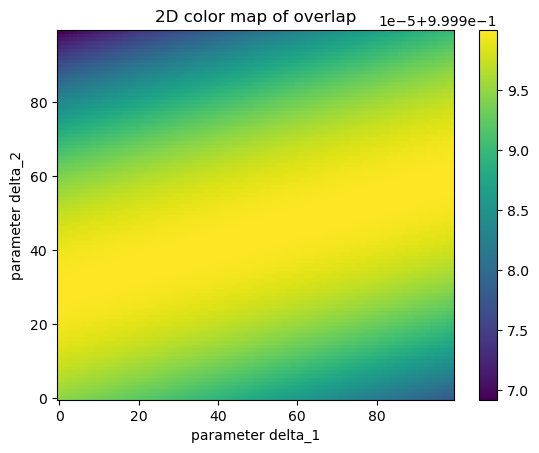

In [11]:


point_ee = 0.1

deva = np.linspace(stationary_point[9] * (1 - point_ee),
                   stationary_point[9] * (1 + point_ee), 100)
devb = np.linspace(stationary_point[10] * (1 - point_ee),
                   stationary_point[10] * (1 + point_ee), 100)

Z = np.zeros((len(deva), len(devb)))

for i, a in enumerate(deva):
    for j, b in enumerate(devb):
        sp = [1.38155436e+01, 9.99981186e+00, 8.00037769e-01,
              7.49981068e+00, 4.00001137e-01, 7.85400513e-01,
              9.99999134e-01, 8.99993271e-01, 3.99997763e-01,
              a, b]
        Z[i, j] = to_minimize(sp)

plt.figure()
plt.imshow(Z, aspect='auto', origin='lower')
plt.xlabel("parameter delta_1")
plt.ylabel("parameter delta_2")
plt.title("2D color map of overlap")
plt.colorbar()
plt.show()


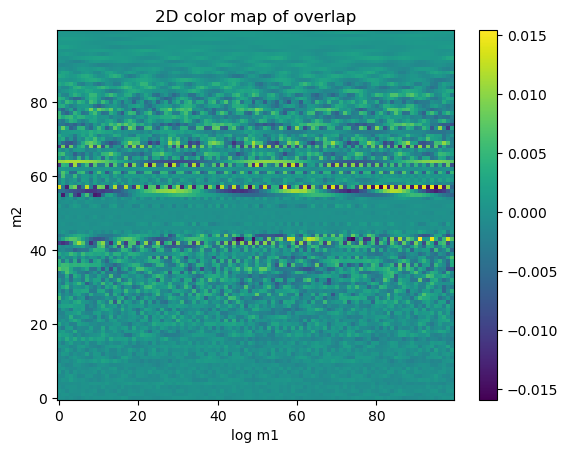

In [12]:
point_ee = 0.1

mas1 = np.linspace(stationary_point[0] * (1 - point_ee),
                   stationary_point[0] * (1 + point_ee), 100)
mas2 = np.linspace(stationary_point[1] * (1 - point_ee),
                   stationary_point[1] * (1 + point_ee), 100)

Z = np.zeros((len(deva), len(devb)))

for i, a in enumerate(mas1):
    for j, b in enumerate(mas2):
        sp = [a, b, 8.00037769e-01,
              7.49981068e+00, 4.00001137e-01, 7.85400513e-01,
              9.99999134e-01, 8.99993271e-01, 3.99997763e-01,
              stationary_point[9], stationary_point[10]]
        Z[i, j] = to_minimize(sp)

plt.figure()
plt.imshow(Z, aspect='auto', origin='lower')
plt.xlabel("log m1")
plt.ylabel("m2")
plt.title("2D color map of overlap")
plt.colorbar()
plt.show()

[ 3.30420357e-05 -1.88140000e-04  3.77690000e-05 -1.89320000e-04
  1.13700000e-06  2.34960255e-06 -8.66000000e-07 -6.72900000e-06
 -2.23700000e-06  2.08333075e-05 -1.49625117e-05]


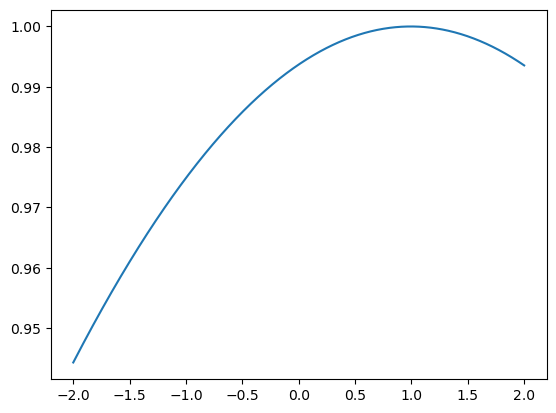

In [ ]:
stationary_point=np.array([1.38155436e+01,  9.99981186e+00,  8.00037769e-01,7.49981068e+00,  4.00001137e-01,  7.85400513e-01,9.99999134e-01,8.99993271e-01,  3.99997763e-01,2.08333075e-05, -1.49625117e-05])
param_truth_in=np.array([np.log(m1), m2, .8, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e])
deviation = stationary_point - param_truth_in
print(deviation)
lin_1_1=np.linspace(-2,2,1000)
Z=[]
for i in lin_1_1:
    params_ = param_truth_in + deviation * i
    # print(params_)
    Z.append(to_minimize(params_))
plt.plot(lin_1_1,Z)


In [5]:
import numpy as np
c=np.array([[1,2,5],[1,2,3]])
c.shape

(2, 3)